# 1D OSIRIS Photon Kinetics Tests and General Analysis Notebook

This notebook contains various tests and random functions I used throughout the course of testing the 1D photon kinetic code written for OSIRIS. It uses my own Python analysis code I've written called simutils.

## Needed Imports

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

from simutils.readers import osiris_load_density, osiris_load_efield

In [3]:
# Autoreload the simutils package whenever you make a change to the source code
%load_ext autoreload
%autoreload 2

In [4]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy.constants as const
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import shutil
from scipy.signal import hilbert
from matplotlib.colors import LinearSegmentedColormap
from scipy.fft import fft, fftfreq, fftshift
from tftb.processing import WignerVilleDistribution
from tftb.processing import PseudoWignerVilleDistribution
from tftb.processing import Spectrogram
from matplotlib.colors import PowerNorm
from matplotlib import cm
import matplotlib
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
import math

## Needed Functions

### 1) Simple photon density snapshot

### 4) Plot the photon distribution on top of the Wigner transform of the EM field

In [17]:
def animate_laser_wigner(dir, xi_min = float('NaN'), z_step = 1, cbarpad = 0.1, n_sigma_interference = 3, figsize = (16, 10), smooth_window_per_dxi = 0.047, nlim = np.array([]), klim = np.array([]), wig_cutoff = 0.01, dump_interval = 1):
    dir = "Plots/"+dir
    
    # NOTE THAT smooth_window_per_dxi = 0.047 ORIGINALLY
    
    if os.path.exists(dir):
        shutil.rmtree(dir)
    os.makedirs(dir)
    
    def next_even(n):
        return n if n % 2 == 0 else n + 1
    
    total_dumps = osiris_get_total_dumps()
    dt = osiris_get_run_info("dt")
    ndumps = osiris_get_run_info("ndump")
    dt_dump = dt*ndumps
    xi = osirisLoadGrid(0)[::z_step]
    dxi = osirisGridSpacing(0)*z_step
    if isnan(xi_min):
        xi_min = xi[0]
    xi_inds = (xi>=xi_min)
    xi = xi[xi_inds]
    k = np.fft.fftshift(np.fft.fftfreq(len(xi), d=dxi))

    dt_pkt = ndumps*0.03799
    
    for dump in range(0, total_dumps, dump_interval):
        fig, ax1 = plt.subplots(figsize = figsize)
        ax2 = ax1.twinx()
        
        E_x = osirisLoadEField(dump, component = 2)[::z_step][xi_inds]
#         n_p = np.abs(osirisLoadDensity(dump, species = 'plasma'))[::z_step][xi_inds]
        
        wig = WignerVilleDistribution(np.pad(E_x, (0, next_even(np.size(E_x)) - np.size(E_x)), 'constant'))
        W_E, xi_wig, f_wig = wig.run()
#         gradn_p = savgol_filter(np.gradient(savgol_filter(n_p, window_length=next_even(int(smooth_window_per_dxi*np.size(xi)))+1, polyorder=3), dxi), window_length = next_even(int(smooth_window_per_dxi*np.size(xi)))+1, polyorder = 3)
        
        n_p_pkt_full = np.abs(osirisLoadDensity(dump, species='plasma', path=''))
        xi_pkt = np.linspace(xi[0], xi[-1], len(n_p_pkt_full))
        xi_inds_pkt = xi_pkt >= xi_min
        xi_pkt = xi_pkt[xi_inds_pkt]
        n_p_pkt = n_p_pkt_full[xi_inds_pkt]
        dxi_pkt = xi_pkt[1] - xi_pkt[0]
        gradn_p_pkt = savgol_filter(np.gradient(savgol_filter(n_p_pkt, 
                                    window_length=next_even(int(smooth_window_per_dxi*np.size(xi_pkt)))+1, 
                                                              polyorder=3), dxi_pkt), 
                                    window_length=next_even(int(smooth_window_per_dxi*np.size(xi_pkt)))+1, 
                                                              polyorder=3)
        
        # Put xi and f into real units, take positive frequencies
        xi_wig = dxi*xi_wig + xi[0]
        nbin = int(np.size(f_wig)/2)
        f_wig = f_wig[:nbin]/dxi
        W_E = W_E[:nbin, :]
        k_wig = 2*pi*f_wig
        print('Frame %d of %d calculated' % (dump+1, total_dumps))
        
        # Mask signalless areas and interference terms
#         E_k = fft(E_x)
#         k_fft = 2*k_wig
#         powspectrum = np.abs(E_k[:(np.size(xi) // 2 + 1)])**2
#         power = np.abs(E_x)**2
#         xi_centroid = np.sum(xi*power)/np.sum(power)
#         sigma_xi = np.sqrt(np.sum(xi**2*power)/np.sum(power) - xi_centroid**2)
#         k_centroid = np.sum(k_fft*powspectrum)/np.sum(powspectrum)
#         sigma_k = np.sqrt(np.sum(k_fft**2*powspectrum)/np.sum(powspectrum) - k_centroid**2)
        E_k = fft(E_x)
        k_fft = 2*k_wig
        powspectrum = np.abs(E_k[:(np.size(E_x) // 2 + 1)])**2
        min_len = min(len(k_fft), len(powspectrum))
        k_fft = k_fft[:min_len]
        powspectrum = powspectrum[:min_len]
        power = np.abs(E_x)**2
        xi_centroid = np.sum(xi*power)/np.sum(power)
        sigma_xi = np.sqrt(np.sum(xi**2*power)/np.sum(power) - xi_centroid**2)
        k_centroid = np.sum(k_fft*powspectrum)/np.sum(powspectrum)
        sigma_k = np.sqrt(np.sum(k_fft**2*powspectrum)/np.sum(powspectrum) - k_centroid**2)

        [Xi, K] = np.meshgrid(xi_wig, k_wig)
        W_E[np.abs(W_E) < wig_cutoff*np.max(np.abs(W_E))] = 0
        W_E[np.abs(K - k_centroid) > n_sigma_interference*sigma_k] = 0
        W_E[Xi < (xi_centroid - 2*sigma_xi)] = 0
        W_E = np.ma.masked_where(W_E == 0, W_E)
        

        # Apply alpha gradient to plot
        linnorm = PowerNorm(1, vmin=np.min(np.abs(W_E)), vmax=np.max(np.abs(W_E)))
        sqrtnorm = PowerNorm(0.5, vmin=np.min(np.abs(W_E)), vmax=np.max(np.abs(W_E)))
        
#         wigpc = ax2.pcolormesh(xi_wig+dump*dt_dump, k_wig, np.abs(W_E), shading='auto', cmap = 'YlOrRd')
#         wigpc.set_alpha(sqrtnorm(np.abs(W_E))/np.max(sqrtnorm(np.abs(W_E))))
#         cbar = fig.colorbar(cm.ScalarMappable(norm = linnorm, cmap = 'YlOrRd'), ax = ax2, pad = cbarpad)
#         cbar.set_label(r'$e^2W_E/(m_e^2 \omega_{p0} c^3)$', fontsize = 24)
#         cbar.ax.tick_params(labelsize = 24)
        cont = ax2.contour(xi_wig, k_wig, np.abs(W_E), np.max(np.abs(W_E))*np.sort(np.array([np.exp(-0.25), np.exp(-0.5), np.exp(-1), np.exp(-2)])), colors = 'black', linewidths = 0.5)
        z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles = 'photons')
        h, xedges, yedges = np.histogram2d(z, p1, bins = [xi_wig[::10]+dump*dt_dump, k_wig[::10]], weights = wgt, density = True)
        xi_wig[::10]+dump*dt_dump
        #return h, xedges, yedges
        h = np.transpose(h)
        im = ax2.pcolormesh(xi_wig[::10][1:], k_wig[::10][1:], h, shading = 'gouraud', cmap = 'turbo')
        sqrtnorm = PowerNorm(0.5, vmin=np.min(np.abs(h)), vmax=np.max(np.abs(h)))
        im.set_alpha(sqrtnorm(np.abs(h))/np.max(sqrtnorm(np.abs(h))))
        if (np.size(klim) > 0):
            ax2.set_ylim(klim[0], klim[1])
        ax2.set_xlabel(r'$k_{p0}\xi$', fontsize = 24)
        ax2.set_ylabel(r'$k/k_{p0}$', fontsize = 24)
        ax2.tick_params(axis = 'both', labelsize = 24)
        ax2.set_title('Wigner Transform of Laser Pulse E-Field in Wakefield | $\omega_{p0}t$ = %f' %(dt_dump*dump), fontsize = 24)
        
        ax1.plot(xi_pkt, gradn_p_pkt, color = 'blue', label = r'$\frac{1}{k_{p0} n_0} \frac{\partial n_e}{\partial \xi}$', linewidth = 2)
        ax1.plot(xi_pkt, n_p_pkt, color = 'green', linestyle = 'dashed', label = r'$\frac{n_e}{n_0}$', linewidth = 2)
        if (np.size(nlim) > 0):
            ax1.set_ylim(nlim[0], nlim[1])
        ax1.set_ylabel('electron density or smoothed density gradient', fontsize = 24)
        ax1.grid()
        ax1.legend(fontsize = 24)
        ax1.set_xlabel(r'$k_{p0}\xi$', fontsize = 24)
        ax1.tick_params(axis = 'both', labelsize = 24)
        
        
        fig.tight_layout()
        fig.savefig(dir + "/frame%d.png" %(dump), bbox_inches = "tight", facecolor = "white")
        print('Frame %d of %d plotted' % (dump+1, total_dumps))
        #cbar.remove()
        ax1.cla()
        ax2.cla()
        fig.clf()
        

In [18]:
def animate_laser_wigner(dir, xi_min=float('NaN'), z_step=1, cbarpad=0.1, n_sigma_interference=3,
                          figsize=(16, 10), smooth_window_per_dxi=0.06, smooth_window_per_dxi_pkt=0.01,
                          nlim=np.array([]), klim=np.array([]), wig_cutoff=0.01, dump_interval=1,
                          k_laser=20):
    dir = "Plots/" + dir
    if os.path.exists(dir):
        shutil.rmtree(dir)
    os.makedirs(dir)

    def next_even(n):
        return n if n % 2 == 0 else n + 1

    total_dumps = osiris_get_total_dumps()
    dt = osiris_get_run_info("dt")
    ndumps = osiris_get_run_info("ndump")
    dt_dump = dt * ndumps

    xi = osirisLoadGrid(0)[::z_step]
    dxi = osirisGridSpacing(0) * z_step
    if np.isnan(xi_min):
        xi_min = xi[0]
    xi_inds = (xi >= xi_min)
    xi = xi[xi_inds]

    # --- PKT grid, loaded ONCE using the same fixed-dump-0 pattern as EM's xi ---
    xi_pkt = osirisLoadGrid(0, species='plasma', ms_dir='MS_pkt')[::z_step]
    dxi_pkt = osirisGridSpacing(0, species='plasma', ms_dir='MS_pkt') * z_step
    xi_inds_pkt = (xi_pkt >= xi_min)
    xi_pkt = xi_pkt[xi_inds_pkt]

    for dump in range(0, total_dumps, dump_interval):
        fig, ax1 = plt.subplots(figsize=figsize)
        ax2 = ax1.twinx()

        E_x = osirisLoadEField(dump, component=2)[::z_step][xi_inds]

        # --- EM background plasma density and smoothed gradient ---
        n_p_em = np.abs(osirisLoadDensity(dump, species='plasma', ms_dir='MS'))[::z_step][xi_inds]
        gradn_p_em = savgol_filter(
            np.gradient(
                savgol_filter(n_p_em,
                               window_length=next_even(int(smooth_window_per_dxi * np.size(xi))) + 1,
                               polyorder=3),
                dxi),
            window_length=next_even(int(smooth_window_per_dxi * np.size(xi))) + 1,
            polyorder=3)

        wig = WignerVilleDistribution(np.pad(E_x, (0, next_even(np.size(E_x)) - np.size(E_x)), 'constant'))
        W_E, xi_wig, f_wig = wig.run()

        # --- PKT background plasma density and smoothed gradient ---
        n_p_pkt_full = np.abs(osirisLoadDensity(dump, species='plasma', ms_dir='MS_pkt'))
        n_p_pkt = n_p_pkt_full[::z_step][xi_inds_pkt]
        gradn_p_pkt = np.gradient(n_p_pkt, dxi_pkt)

        # Put xi and f into real units, take positive frequencies
        xi_wig = dxi * xi_wig + xi[0]
        nbin = int(np.size(f_wig) / 2)
        f_wig = f_wig[:nbin] / dxi
        W_E = W_E[:nbin, :]
        k_wig = 2 * np.pi * f_wig
        print('Frame %d of %d calculated' % (dump + 1, total_dumps))

        k_full = 2 * np.pi * np.fft.fftfreq(len(xi), d=dxi)
        E_k = fft(E_x)
        pos_mask = k_full > 0
        k_pos = k_full[pos_mask]
        powspectrum = np.abs(E_k[pos_mask])**2

        power = np.abs(E_x)**2
        xi_centroid = np.sum(xi * power) / np.sum(power)
        sigma_xi = np.sqrt(np.sum(xi**2 * power) / np.sum(power) - xi_centroid**2)

        k_centroid = np.sum(k_pos * powspectrum) / np.sum(powspectrum)
        sigma_k = np.sqrt(np.sum((k_pos - k_centroid)**2 * powspectrum) / np.sum(powspectrum))

        [Xi, K] = np.meshgrid(xi_wig, k_wig)
        W_E[np.abs(W_E) < wig_cutoff * np.max(np.abs(W_E))] = 0
        W_E[np.abs(K - k_centroid) > n_sigma_interference * sigma_k] = 0
        W_E[Xi < (xi_centroid - 2 * sigma_xi)] = 0
        W_E = np.ma.masked_where(W_E == 0, W_E)

        k_wig_norm = k_wig / k_laser
        cont = ax2.contour(xi_wig, k_wig_norm, np.abs(W_E),
                            np.max(np.abs(W_E)) * np.sort(np.array([np.exp(-0.25), np.exp(-0.5), np.exp(-1), np.exp(-2)])),
                            colors='black', linewidths=0.5)

        z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles='photons')

        h, xedges, yedges = np.histogram2d(z, p1 / k_laser, bins=[xi_wig[::10] + dump*dt_dump, k_wig_norm[::10]],
                                            weights=wgt, density=True)
        h = np.nan_to_num(h, nan=0.0)
        h = np.transpose(h)

        x_centers = 0.5 * (xedges[1:] + xedges[:-1]) - dump * dt_dump
        k_centers = 0.5 * (yedges[1:] + yedges[:-1])

        im = ax2.pcolormesh(x_centers, k_centers, h, shading='gouraud', cmap='turbo')

        h_max = np.max(np.abs(h))
        if h_max > 0:
            sqrtnorm = PowerNorm(0.5, vmin=0, vmax=h_max)
            im.set_alpha(sqrtnorm(np.abs(h)) / np.max(sqrtnorm(np.abs(h))))
        else:
            im.set_alpha(0)

        if np.size(klim) > 0:
            ax2.set_ylim(klim[0], klim[1])
        ax2.set_xlabel(r'$k_{p0}\xi$', fontsize=24)
        ax2.set_ylabel(r'$k/k_{p0}$', fontsize=24)
        ax2.tick_params(axis='both', labelsize=24)
        ax2.set_title(r'Wigner Transform of Laser Pulse E-Field in Wakefield | $\omega_{p0}t$ = %f' % (dt_dump * dump), fontsize=24)

        ax1.plot(xi, n_p_em, color='darkorange', linestyle='dashed',
                  label=r'EM: $\frac{n_e}{n_0}$', linewidth=2)
        ax1.plot(xi, gradn_p_em, color='red',
                  label=r'EM: $\frac{1}{k_{p0} n_0} \frac{\partial n_e}{\partial \xi}$', linewidth=2)
        ax1.plot(xi_pkt, n_p_pkt, color='green', linestyle='dashed',
                  label=r'PKT: $\frac{n_e}{n_0}$', linewidth=2)
        ax1.plot(xi_pkt, gradn_p_pkt, color='blue',
                  label=r'PKT: $\frac{1}{k_{p0} n_0} \frac{\partial n_e}{\partial \xi}$', linewidth=2)
        if np.size(nlim) > 0:
            ax1.set_ylim(nlim[0], nlim[1])
        ax1.set_ylabel('electron density or smoothed density gradient', fontsize=24)
        ax1.grid()
        ax1.legend(fontsize=24)
        ax1.set_xlabel(r'$k_{p0}\xi$', fontsize=24)
        ax1.tick_params(axis='both', labelsize=24)
        ax1.set_xlim(-65, 0)

        fig.tight_layout()
        fig.savefig(dir + "/frame%d.png" % (dump), bbox_inches="tight", facecolor="white")
        print('Frame %d of %d plotted' % (dump + 1, total_dumps))
        ax1.cla()
        ax2.cla()
        fig.clf()

In [ ]:
h, xedges, yedges = animate_laser_wigner('wigner', z_step = 10, dump_interval = 1, klim = np.array([0.9, 1.6]), nlim = np.array([-4, 4]), figsize = (16, 10))

## Test 1: Beam-Driven Plasma Wakefield Photon Acceleration

## Test 2: Laser-Driven Feedback Test

## Test 3: Replicate Figures From Reitsma

## Test 4: Can we get **INSANE** frequency shifts??

# Recreation of Alec's Figure

In [22]:
def smooth_1d(arr, passes=15):
    a = arr.copy()
    for _ in range(passes):
        tmp = 0.25*np.roll(a,1) + 0.5*a + 0.25*np.roll(a,-1)
        tmp[0], tmp[-1] = a[0], a[-1]
        a = tmp
    return a

def plot_hilbert_comparison(dump, omega0, k_laser=1, xi_min=None, z_step=1, figsize=(16, 12),
                             klim=None):
    xi = osirisLoadGrid(dump)[::z_step]
    dxi = osirisGridSpacing(dump) * z_step
    if xi_min is None:
        xi_min = xi[0]
    xi_inds = (xi >= xi_min)
    xi = xi[xi_inds]

    E_x = osirisLoadEField(dump, component=2)[::z_step][xi_inds]

    # --- reconstruct A from E (see docstring) ---
    A = E_x / omega0

    # --- Hilbert transform: analytic signal, unwrap phase, low-pass, differentiate ---
    A_H = hilbert(A)
    env = np.abs(A_H)

    om_x = np.unwrap(np.angle(A_H))
    om_x = np.fft.fft(om_x)
    k_grid = 2 * np.pi * np.fft.fftfreq(len(xi), d=dxi)
    om_x *= np.sinc(k_grid * dxi / 2 / np.pi)**8   # low-pass filter, same as reference
    om_x = np.real(np.fft.ifft(om_x))
    om_x = np.gradient(om_x, dxi)   # local wavenumber = d(phase)/dx

    N_pho_A = env**2   # matches OSIRIS's n_pho = |A|^2 convention directly

    # --- PKT's actual photon data ---
    n_pho_pkt = np.abs(osirisLoadDensity(dump, species='photons', ms_dir='MS_pkt'))
    xi_pkt = osirisLoadGrid(dump, species='photons', ms_dir='MS_pkt')

    # --- normalize EACH curve to its own peak (dimensionless, 0-1) ---
    n_pho_pkt_plot = smooth_1d(n_pho_pkt)
    N_pho_A_plot = N_pho_A

    z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles='photons')

    fig, axs = plt.subplots(3, 1, figsize=figsize)

    # --- Panel 1: photon density comparison ---
    axs[0].plot(xi_pkt, n_pho_pkt_plot, 'k', label=r'$n_{pho}(x)$ [PKT]')
    axs[0].plot(xi, N_pho_A_plot, 'r--', label=r'$|\mathcal{H}(A)|^2(x)$ [EM]')
    axs[0].set_xlabel('$x$')
    axs[0].set_ylabel(r'$n_{pho}$')
    axs[0].legend()
    
    # --- Panel 2: phase space + local wavenumber overlay (the one you asked about) ---
    x_range = (xi.min(), xi.max())
    k_range = tuple(klim) if klim is not None else (p1.min(), p1.max())

    h, xedges, yedges = np.histogram2d(z, p1, bins=[200, 200], weights=wgt,
                                        range=[x_range, k_range], density=True)
    h = np.nan_to_num(h, nan=0.0)
    x_centers = 0.5 * (xedges[1:] + xedges[:-1])
    k_centers = 0.5 * (yedges[1:] + yedges[:-1])
    axs[1].pcolormesh(x_centers, k_centers, h.T, cmap='viridis')
    axs[1].plot(xi, om_x, 'r--', linewidth=1, label=r'$\nabla\theta[\mathcal{H}(A)]$')
    if klim is not None:
        axs[1].set_ylim(klim[0], klim[1])
    else:
        axs[1].set_ylim(k_centers.min(), k_centers.max())
    axs[1].set_xlim(x_range)   # cover the full simulation domain, matching panel 1
    axs[1].set_ylabel('$k$')
    axs[1].set_xlabel('$x$')
    axs[1].legend(loc='upper left')

    # --- Panel 3: k-spectrum comparison ---
    spec_pho, k_pho_edges = np.histogram(p1, bins=200, weights=wgt, density=True)
    k_pho_centers = 0.5 * (k_pho_edges[1:] + k_pho_edges[:-1])

    A_k_full = fft(A) * dxi
    k_full = 2 * np.pi * np.fft.fftfreq(len(xi), d=dxi)
    pos_mask = k_full > 0
    k_fft = k_full[pos_mask]
    spectrum_field = np.abs(A_k_full[pos_mask])**2 * np.abs(k_fft)

    axs[2].plot(k_pho_centers / k_laser, spec_pho, 'k', label=r'$\tilde{n}_{pho}(k)$ [PKT]')
#     axs[2].plot(k_fft / k_laser, spectrum_field, 'r--', label=r'$|\tilde{A}(k)|^2|k|$ [EM]')
    axs[2].set_xlabel('$k$')
    axs[2].set_ylabel(r'$\tilde{n}_{pho}$')
    if klim is not None:
        axs[2].set_xlim(klim[0] / k_laser, klim[1] / k_laser)
    axs[2].legend()

    fig.tight_layout()
    return fig, axs

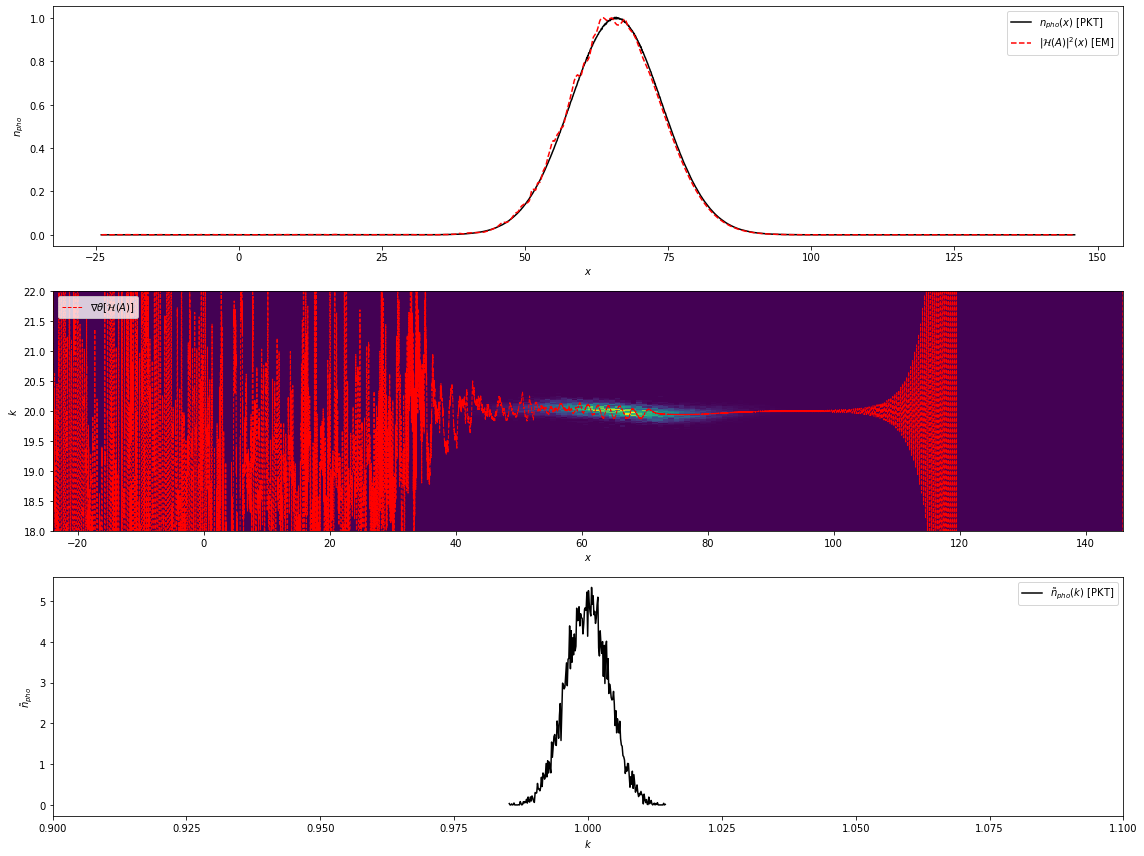

In [26]:
fig, axs = plot_hilbert_comparison(dump=5, omega0=20.0, k_laser=20.0, klim=[18, 22])

In [20]:
def plot_phase_space_with_local_k(dump, omega0, xi_min=None, z_step=1, klim=None, figsize=(16, 5), window_halfwidth=None):

    dt = osiris_get_run_info("dt")
    ndumps = osiris_get_run_info("ndump")
    dt_dump = dt * ndumps
    
    xi_full = osirisLoadGrid(dump)[::z_step]
    dxi = osirisGridSpacing(dump) * z_step
    E_x_full = osirisLoadEField(dump, component=2)[::z_step]
    A_full = E_x_full / omega0

    A_H = hilbert(A_full)
    om_x = np.unwrap(np.angle(A_H))
    om_x = np.fft.fft(om_x)
    k_grid = 2 * np.pi * np.fft.fftfreq(len(xi_full), d=dxi)
    om_x *= np.sinc(k_grid * dxi / 2 / np.pi) ** 8
#     om_x *= np.sinc(k_grid * dxi / 2 / np.pi) ** 16 
    om_x = np.real(np.fft.ifft(om_x))
    om_x = np.gradient(om_x, dxi)
    om_x = savgol_filter(om_x, window_length=51, polyorder=3)

    # only now cut down to your plotting window
    mask = xi_full >= (xi_min if xi_min is not None else xi_full[0])
    xi, om_x = xi_full[mask], om_x[mask]

    z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles='photons')
    
    # --- center the x-window on the photon distribution's charge-weighted centroid ---
    z_centroid = np.sum(z * wgt) / np.sum(wgt)
    if window_halfwidth is None:
        sigma_z = np.sqrt(np.sum((z - z_centroid)**2 * wgt) / np.sum(wgt))
        window_halfwidth = 6 * sigma_z   # tune multiplier to taste
    x_range = (z_centroid - window_halfwidth, z_centroid + window_halfwidth)
    # clip to available grid so we don't request data outside xi_full
    x_range = (max(x_range[0], xi.min()), min(x_range[1], xi.max()))

#     x_range = (xi.min(), xi.max())
    k_range = tuple(klim) if klim is not None else (p1.min(), p1.max())
    h, xedges, yedges = np.histogram2d(
        z, p1, bins=[200, 200], weights=wgt,
        range=[x_range, k_range], density=True
    )
    h = np.nan_to_num(h, nan=0.0)
    x_centers = 0.5 * (xedges[1:] + xedges[:-1])
    k_centers = 0.5 * (yedges[1:] + yedges[:-1])

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    ax.pcolormesh(x_centers, k_centers, h.T, cmap='viridis')
    ax.plot(xi, om_x, 'r--', linewidth=1, label=r'$\nabla\theta[\mathcal{H}(A)]$')
    if klim is not None:
        ax.set_ylim(klim[0], klim[1])
    else:
        ax.set_ylim(k_centers.min(), k_centers.max())
    ax.set_xlim(x_range)
    ax.set_ylabel('$k$', fontsize=24)
    ax.set_xlabel('$x$', fontsize=24)
    ax.tick_params(axis='both', labelsize=20)
    ax.legend(loc='upper left', fontsize=18)
    ax.set_title(r'$\omega_{p0}t$ = %.1f' % (dt_dump * dump), fontsize=22)
    fig.tight_layout()
    return fig, ax

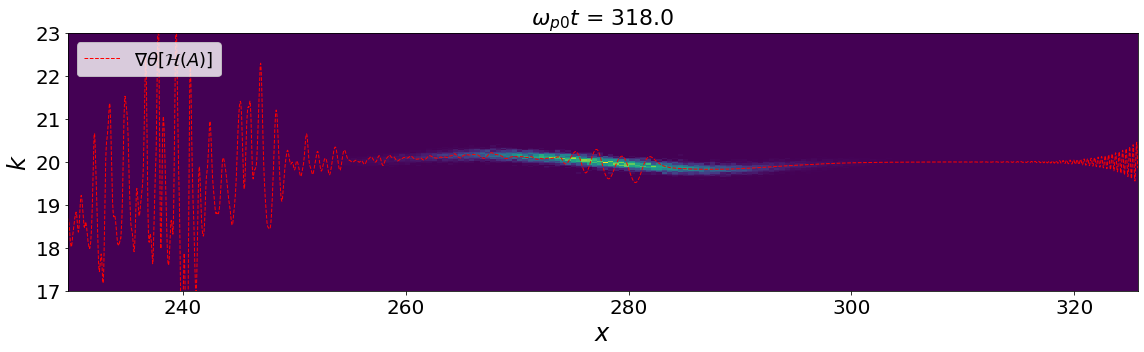

In [23]:
fig, ax = plot_phase_space_with_local_k(dump=15, omega0=20.0, z_step=1, klim=[17, 23], figsize=(16, 5))

In [68]:
def plot_phase_space_with_local_k(dump, omega0, xi_min=None, z_step=1, klim=None, figsize=(16, 5)):
    
    xi_full = osirisLoadGrid(dump)[::z_step]
    dxi = osirisGridSpacing(dump) * z_step
    E_x_full = osirisLoadEField(dump, component=2)[::z_step]
    E_x2_full = osirisLoadEField(dump, component=3)[::z_step]

    # --- true analytic signal for circular polarization, no scipy.hilbert needed ---
    A_complex = (E_x_full + 1j * E_x2_full) / omega0

    om_x = np.unwrap(np.angle(A_complex))
    om_x = np.fft.fft(om_x)
    k_grid = 2 * np.pi * np.fft.fftfreq(len(xi_full), d=dxi)
    om_x *= np.sinc(k_grid * dxi / 2 / np.pi) ** 8
    om_x = np.real(np.fft.ifft(om_x))
    om_x = np.gradient(om_x, dxi)

    mask = xi_full >= (xi_min if xi_min is not None else xi_full[0])
    xi, om_x = xi_full[mask], om_x[mask]

    z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles='photons')
    x_range = (xi.min(), xi.max())
    k_range = tuple(klim) if klim is not None else (p1.min(), p1.max())
    h, xedges, yedges = np.histogram2d(
        z, p1, bins=[200, 200], weights=wgt,
        range=[x_range, k_range], density=True
    )
    h = np.nan_to_num(h, nan=0.0)
    x_centers = 0.5 * (xedges[1:] + xedges[:-1])
    k_centers = 0.5 * (yedges[1:] + yedges[:-1])

    fig, ax = plt.subplots(figsize=figsize)
    ax.pcolormesh(x_centers, k_centers, h.T, cmap='viridis')
    ax.plot(xi, om_x, 'r--', linewidth=1, label=r'$\nabla\theta[\mathcal{H}(A)]$')
    if klim is not None:
        ax.set_ylim(klim[0], klim[1])
    else:
        ax.set_ylim(k_centers.min(), k_centers.max())
    ax.set_xlim(x_range)
    ax.set_ylabel('$k$')
    ax.set_xlabel('$x$')
    ax.legend(loc='upper left')
    fig.tight_layout()
    return fig, ax

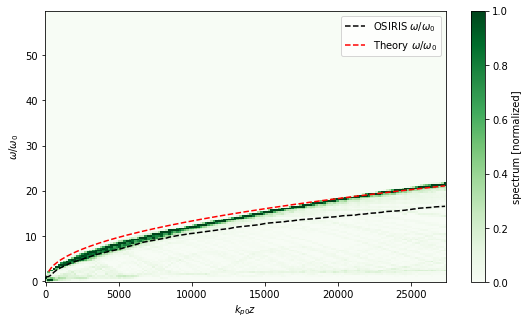

In [22]:
def model_func(x, *params):
    return params[0] + params[1] / (params[2] + x) ** params[3]


def dump_number(fn):
    m = re.search(r'(\d+)\.h5$', fn)
    return int(m.group(1)) if m else -1


def build_and_plot(
    driver_head_x1=20.0, nd0_np0=0.6, kp0Ld0=1.0, nc0_np0=25.93,
    ramp_width=1.0, v_g_ref=1.0,
    t_offset=0.0, z_start=0.0, xi_bins=None, omega_bins=None,
    kp0z_final=200000.0, core_n_sigma=5.0, file_stride = 100,
):
    if xi_bins is None:
        xi_bins = np.linspace(0, 25, 150)
    if omega_bins is None:
        omega_bins = np.linspace(0, 60, 150)
    omega0 = np.sqrt(nc0_np0)
    ramp_end = driver_head_x1 + ramp_width

    # --- fit density taper (used for the particle omega calculation) ---
    kp0z_fit, n_n0_fit, k_kp0_sq_fit = depa.get_pwpa_profile(
        nc0_np0, nd0_np0, kp0Ld0, kp0z_final=kp0z_final, n_steps=1601
    )
    taper_params, _ = curve_fit(
        model_func, kp0z_fit, n_n0_fit,
        p0=[0.25, 1.1, 20.0, 0.15]
    )

    def density_profile(x1):
        x1 = np.asarray(x1, dtype=float)
        s = x1 - ramp_end
        taper = model_func(np.clip(s, 0, None), *taper_params)
        return np.where(
            x1 <= driver_head_x1, 0.0,
            np.where(x1 <= ramp_end, (x1 - driver_head_x1) / ramp_width, taper)
        )

    # --- sort files numerically by dump number, not lexicographically ---
    photon_files = sorted(glob.glob("MS/RAW/photons/RAW-photons-*.h5"), key=dump_number)[::file_stride]
    if not photon_files:
        raise FileNotFoundError("No RAW photon HDF5 files found in MS/RAW/photons/")

    envelope_img, spectrum_img, times, centroid_xi, centroid_omega = [], [], [], [], []
    for fn in photon_files:
        with h5py.File(fn, "r") as f:
            ds = f["x1"]
            if ds.shape == () or ds.shape[0] == 0:
                continue
            x1 = ds[:]
            p1 = f["p1"][:]
            q = f["q"][:]
            t = float(f.attrs["TIME"][0])
        w = np.abs(q)

        # single shared reference frame for all particles at this dump
        xi = x1 - v_g_ref * (t - t_offset)

        
        w_sum = np.sum(w)
        if w_sum <= 0 or w.size == 0:
            # no valid photon macroparticles in this dump -- skip it
            continue 

        # --- gate to the pulse core before computing omega/centroid, so
        #     stray/separated macroparticles (e.g. low-p1 tail members that
        #     have drifted at a different group velocity) don't get counted
        #     with full weight in the spectrum or centroid ---
        xi_c = np.average(xi, weights=w)
        xi_spread = np.sqrt(np.average((xi - xi_c) ** 2, weights=w))
        core_mask = np.abs(xi - xi_c) < core_n_sigma * xi_spread

        x1_core = x1[core_mask]
        p1_core = p1[core_mask]
        w_core = w[core_mask]
        xi_core = xi[core_mask]

        n_local_core = density_profile(x1_core)
        omega_core = np.sqrt(p1_core ** 2 + n_local_core)
        omega_over_omega0_core = omega_core / omega0

        # envelope panel uses the full (ungated) population, so the real
        # spatial spread/tail is still visible there
        h_xi, _ = np.histogram(xi, bins=xi_bins, weights=w, density=True)
        envelope_img.append(h_xi)

        h_omega, _ = np.histogram(omega_over_omega0_core, bins=omega_bins,
                                   weights=w_core, density=True)
        spectrum_img.append(h_omega)

        times.append(t)
        centroid_xi.append(xi_c)
        centroid_omega.append(np.average(omega_over_omega0_core, weights=w_core))

    times = np.array(times)
    centroid_xi = np.array(centroid_xi)
    centroid_omega = np.array(centroid_omega)
    envelope_img = np.array(envelope_img).T
    spectrum_img = np.array(spectrum_img).T
    spectrum_img_norm = spectrum_img / (spectrum_img.max(axis=0, keepdims=True) + 1e-30)

    # --- theory overlay, same fitted profile as used for the particle data ---
    valid = times >= z_start
    kp0z_theory = times[valid] - z_start
    k_kp0_theory = np.interp(kp0z_theory, kp0z_fit, np.sqrt(k_kp0_sq_fit))
    theory_omega_over_omega0 = k_kp0_theory / omega0
    theory_t_axis = kp0z_theory + z_start

    plt.figure(figsize=(9, 5))
    im = plt.pcolormesh(times, omega_bins[:-1], spectrum_img_norm, cmap="Greens",
                          shading="auto", vmin=0, vmax=1)
    plt.plot(times, centroid_omega, color="black", linestyle="--", label=r"OSIRIS $\omega/\omega_0$")
    plt.plot(theory_t_axis, theory_omega_over_omega0, color="red", linestyle="--",
              label=r"Theory $\omega/\omega_0$")
    plt.ylabel(r"$\omega/\omega_0$")
    plt.xlabel(r"$k_{p0}z$")
    # plt.set_xlim(0, 5000)   # fixed: was set_xmin, not a real Axes method
    plt.legend()
    plt.colorbar(im, label="spectrum [normalized]")
    return 1


build_and_plot(driver_head_x1=1.0, ramp_width=30.0, nd0_np0=0.8, kp0Ld0=1.0,
                      nc0_np0=25.0, z_start=31.0, omega_bins=np.linspace(0, 60, 150));